In [1]:
%pip install torch torchvision opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /Users/vishal04/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100.0%


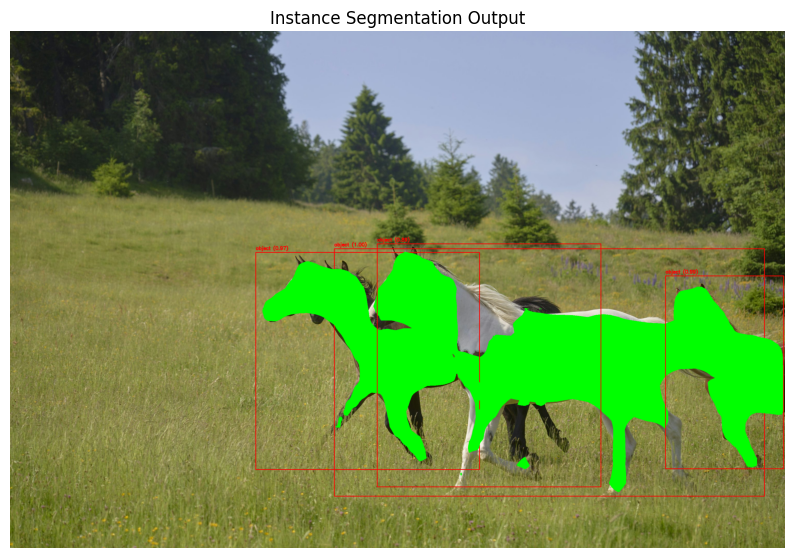

✅ Output saved as output.jpg


In [5]:
# ==============================
# 1. Fix SSL Issue (macOS only)
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())


# ==============================
# 2. Import Libraries
# ==============================
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as F


# ==============================
# 3. Load Pretrained Model
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
model.to(device)
model.eval()


# ==============================
# 4. COCO Labels
# ==============================
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle',
    'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
    'fire hydrant', 'stop sign', 'parking meter', 'bench',
    'bird', 'cat', 'dog', 'horse'
]


# ==============================
# 5. Read Input Image
# ==============================
image_path = "1.jpeg"   # 🔁 Put your image here
image = cv2.imread(image_path)

if image is None:
    raise Exception("❌ Image not found. Check file path.")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# ==============================
# 6. Preprocess Image
# ==============================
image_tensor = F.to_tensor(image).to(device)


# ==============================
# 7. Model Prediction
# ==============================
with torch.no_grad():
    outputs = model([image_tensor])

pred = outputs[0]

boxes = pred['boxes'].detach().cpu().numpy()
labels = pred['labels'].detach().cpu().numpy()
scores = pred['scores'].detach().cpu().numpy()
masks = pred['masks'].detach().cpu().numpy()


# ==============================
# 8. Apply Threshold
# ==============================
threshold = 0.5

for i in range(len(scores)):
    if scores[i] > threshold:
        mask = masks[i, 0]

        # Apply mask color (green)
        image[mask > 0.5] = [0, 255, 0]

        # Draw bounding box
        x1, y1, x2, y2 = boxes[i].astype(int)
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

        # Label text
        label_name = COCO_CLASSES[labels[i]] if labels[i] < len(COCO_CLASSES) else "object"

        cv2.putText(image,
                    f"{label_name} ({scores[i]:.2f})",
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255, 0, 0),
                    2)


# ==============================
# 9. Display Output
# ==============================
plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Instance Segmentation Output")
plt.show()


# ==============================
# 10. Save Output (Optional)
# ==============================
output_path = "output.jpg"
cv2.imwrite(output_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

print(f"✅ Output saved as {output_path}")